# Working with snapshots

The core of `snapAnalysis` is the `snapshot` class, which handles data from one particle type of a single snapshot. In this notebook, we demonstrate a few common workflows for loading and working with simulation particle data. 

In [1]:
from snapanalysis.snap import snapshot
import astropy.units as u # for unit handling

## The snapshot object

For this tutorial, we'll use one of the small snapshots included with `snapAnalysis`'s test suite, which is a low-resolution isolated dark matter halo. To instantiate a `snapshot` object, provide the filename and the particle type you want to work with:

In [2]:
s = snapshot("../tests/example_snaps/cdm_snaps/snap_000.hdf5", 1)

Instantiating a `snapshot` object loads the snapshot's metadata from its header, including time, units (handled via astropy), number of particles, etc. 

In [3]:
print(s.time, s.time_unit)
print(s.G, s.length_unit, s.mass_unit, s.vel_unit)
print(s.N)
print(s.box_size)

0.0 Gyr 0.9777923542981724 Gyr
43021.931322710916 9.99703e-11 km2 kpc / (solMass s2) 1.000000135629411 kpc 10002967845.365513 solMass 1.0 km / s
10000
0.0 kpc


There are also convenience methods for printing the entire snapshot structure, or the entire header.

In [4]:
s.print_structure()

File structure of ../tests/example_snaps/cdm_snaps/snap_000.hdf5

GROUP: Config
KEYS:
       ALLOW_HDF5_COMPRESSION
       DOUBLEPRECISION
       DOUBLEPRECISION_FFTW
       EVALPOTENTIAL
       IMPOSE_PINNING
       MAX_NUMBER_OF_RANKS_WITH_SHARED_MEMORY
       NSOFTCLASSES
       NTYPES
       NUMBER_OF_MPI_LISTENERS_PER_NODE
       OUTPUT_ACCELERATION
       OUTPUT_IN_DOUBLEPRECISION
       OUTPUT_POTENTIAL
       OUTPUT_TIMESTEP
       POSITIONS_IN_64BIT
       RANDOMIZE_DOMAINCENTER
       SELFGRAVITY
DATA SETS:

GROUP: Header
KEYS:
       BoxSize
       Git_commit
       Git_date
       MassTable
       NumFilesPerSnapshot
       NumPart_ThisFile
       NumPart_Total
       Redshift
       Time
DATA SETS:

GROUP: Parameters
KEYS:
       ActivePartFracForNewDomainDecomp
       ArtBulkViscConst
       BoxSize
       ComovingIntegrationOn
       CourantFac
       CpuTimeBetRestartFile
       DesNumNgb
       ErrTolForceAcc
       ErrTolIntAccuracy
       ErrTolTheta
       ErrTolThe

In [5]:
s.print_header()

___________________________________________
Header of ../tests/example_snaps/cdm_snaps/snap_000.hdf5

KEYS
--------
BoxSize: 0.0
Git_commit: b'01e6b1567c93fe1cfaffd499aa55151db2ed4208'
Git_date: b'Tue Mar 2 13:22:03 2021 +0100'
MassTable: [0.00000000e+00 1.79999643e-03 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.79999645e-07]
NumFilesPerSnapshot: 1
NumPart_ThisFile: [    0 10000     0     0     0     1]
NumPart_Total: [    0 10000     0     0     0     1]
Redshift: 0.0
Time: 0.0

DATA SETS
--------


## Loading particle data

`snapshot` objects do NOT automatically load particle data. Instead, the user can specify only which fields they want to work with, to save memory. To load (a) data field(s), use

In [6]:
s.load_particle_data(["Coordinates", "Velocities"])

# once loaded, the data is stored in a dictionary, indexed by field:
print(s.data_fields["Coordinates"])

# you can load masses, positions, and velocities in a single line with
s.read_all()
print(s.data_fields["Masses"])

[[-34.63337414 -66.0694746  172.63700156]
 [-36.79456065 -60.03053335 153.69383798]
 [-30.34222824 -17.90112547 161.11934558]
 ...
 [ 16.34056885 -11.39983141 171.08065064]
 [ 18.99446364 -65.16006591 128.64642553]
 [ 18.09111078 -53.39961967 171.65064279]] kpc
[18005306.43454713 18005306.43454713 18005306.43454713 ...
 18005306.43454713 18005306.43454713 18005306.43454713] solMass


Note that the particle loader will only load a field if it is not already loaded and no filters have been applied to the dataset.

## Centering and Rotations

A common need when working with snapshots is to move to the center-of-mass (COM) frame of a galaxy, in which the z-axis is aligned with the galaxy's angular momentum vector. These can be accomplished quickly via

In [7]:
s.find_and_apply_center()
s.align_angular_momentum()

/Users/haydenfoote/Documents/gradschool/research/code/snapAnalysis/src/snapanalysis/snap.py:468: UserWarning: COM: Minimum number of particles reached before COM converged.
  warnings.warn(


You can also obtain the center of mass without applying the transformation with the following. Note these should be close to zero since we've already applied the centering in the previous cell.

In [8]:
com = s.find_position_center()
com

<Quantity [-2.07299455e-16,  3.95516953e-16, -8.50014503e-16] kpc>

You'll notice the previous two cells gave a warning that the COM did not converge. The centering uses the shrinking-sphere alogrithm described in [Power et al. 2003](https://ui.adsabs.harvard.edu/abs/2003MNRAS.338...14P), in which the COM is computed using successively smaller spheres, stopping when the postiion converges. The test snapshots include too few particles to effectively apply this method using its default parameters, though you can adjust the shrinking rate of the sphere, initial size of the sphere, and other parameters using the kwargs:

In [9]:
s.find_position_center(vol_dec=1.1, r_start=15.*u.kpc, guess=[0,0,0]*u.kpc)

<Quantity [0.10042075, 0.22558081, 0.12055743] kpc>

In [10]:
# find velocity center requires the position center, as it finds the average velocity of particles within a small radius of the position center.  
com_v = s.find_velocity_center(com, r_max=15.*u.kpc)
com_v

<Quantity [-3.40005801e-15, -5.27355937e-16,  1.39081455e-15] km / s>

In [11]:
# angular momentum should be close to [0,0,1]
s.find_angular_momentum_direction()

<Quantity [ 5.73781525e-15, -1.22003948e-15,  1.00000000e+00]>

## Filtering particles

The `select_particles` method allows one to keep a subset of particles according to various criteria. It supports ID ranges and boolean masks. For example, to keep all particles within 15 kpc of the center, use

In [12]:
import numpy as np
r = np.sqrt(np.sum(s.data_fields["Coordinates"]**2, axis=1)) # radial coordinate of all particles
s.select_particles(r < 15*u.kpc)

## Plotting
`snapAnalysis` includes a visualization module with a few basic analysis and plotting tools. If you want to plot something that isn't included out-of-the-box, it should be straightforward to make your own plotting functions using the extracted particle data. If you make your own visualization functions, please consider [contributing them](/CONTRIBUTING.md) through a pull request, or [open an issue](https://github.com/hfoote/snapAnalysis/issues) so that we can implement the plot you want! 

Note that by default, the visualization functions will show a rudimentary version of the plot, but will also return the arrays used to make the plot so you can make them pretty in your own style. For example, let's plot the spherically-averaged density profile of the particles we've selected. 

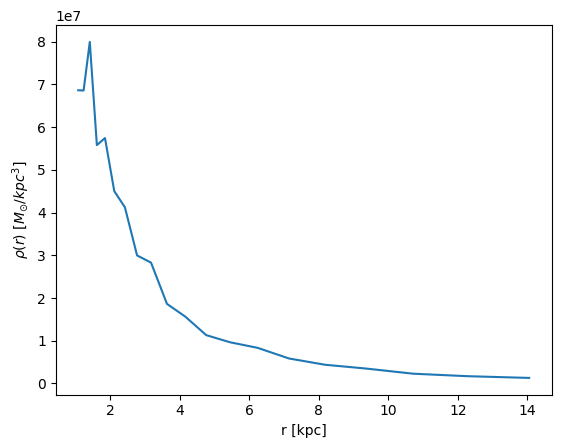

In [13]:
from snapanalysis import vis
# this will be noisy since we're working with a small number of particles
bins, density = vis.density_profile(s, rmin=1., rmax=15., nbins=20, log_bins=True)

[None,
 None,
 Text(0.5, 0, 'Radius [kpc]'),
 Text(0, 0.5, 'Density [$M_\\odot / kpc^3$]')]

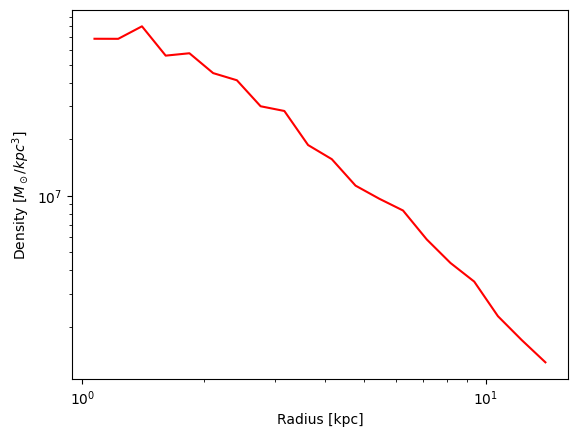

In [14]:
# now, we can make this prettier according to our use-case:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(bins, density, c='r')
ax.set(xscale="log", yscale="log", xlabel="Radius [kpc]", ylabel=r"Density [$M_\odot / kpc^3$]")

As another example, here's a surface density plot of the particles we selected:

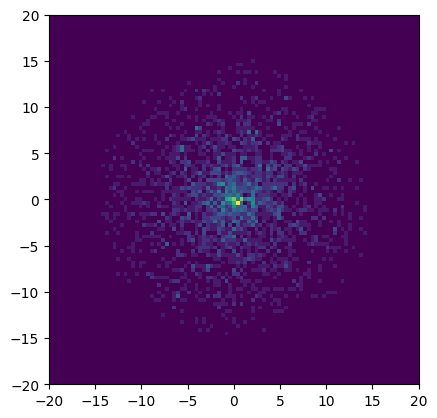

In [15]:
xbins, ybins, surf_density = vis.density_projection(s, bins=np.linspace(-20, 20, 100))

## Misc Analyses

Other analyses are outlined here.

In [16]:
# To find the particle density near a given point,
s.density_points([0,0,0]*u.kpc)

<Quantity [15306612.71950367] solMass / kpc3>

In [17]:
# To calculate the principal axes (and their directions) of the 
# selected particle distribution by diagonalizing the inertia tensor,
s.principal_axes()

(array([2.56199069e+12, 2.49863973e+12, 2.52594940e+12]),
 array([[-0.5373118 ,  0.72543306, -0.43016614],
        [ 0.77115326,  0.62910866,  0.09769822],
        [-0.34149476,  0.27922962,  0.89744758]]))